### Computer Vision: Project

The supermarket chain Good Seed would like to explore whether Data Science can help them adhere to alcohol laws by making sure they do not sell alcohol to people underage. You are asked to conduct that evaluation, so as you set to work, keep the following in mind:

The shops are equipped with cameras in the checkout area which are triggered when a person is buying alcohol
Computer vision methods can be used to determine age of a person from a photo
The task then is to build and evaluate a model for verifying people's age
To start working on the task, you'll have a set of photographs of people with their ages indicated.

## Initialization

In [1]:
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image

## Load Data

The dataset is stored in the `/datasets/faces/` folder, there you can find
- The `final_files` folder with 7.6k photos
- The `labels.csv` file with labels, with two columns: `file_name` and `real_age`

Given the fact that the number of image files is rather high, it is advisable to avoid reading them all at once, which would greatly consume computational resources. We recommend you build a generator with the ImageDataGenerator generator. This method was explained in Chapter 3, Lesson 7 of this course.

The label file can be loaded as an usual CSV file.

In [2]:
labels = pd.read_csv('/datasets/faces/labels.csv')
labels_dir = '/datasets/faces/final_files/'
labels.head()

,file_name,real_age
0,000000.jpg,4
1,000001.jpg,18
2,000002.jpg,80
3,000003.jpg,50
4,000004.jpg,17


## EDA

In [3]:
labels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7591 entries, 0 to 7590
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  7591 non-null   object
 1   real_age   7591 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 118.7+ KB


In [4]:
labels.shape

(7591, 2)

In [5]:
labels.isna().sum()

file_name    0
real_age     0
dtype: int64

In [6]:
labels.duplicated().sum()

0

In [7]:
labels.describe()

,real_age
count,7591.000000
mean,31.201159
std,17.145060
min,1.000000
25%,20.000000
50%,29.000000
75%,41.000000
max,100.000000


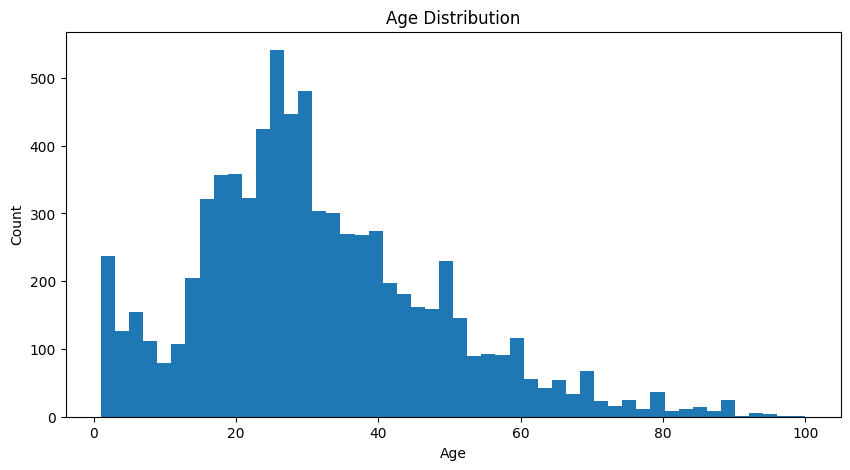

In [8]:
plt.figure(figsize=(10,5))
plt.hist(labels['real_age'], bins=50)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

In [9]:
bins = [0, 10, 20, 30, 40, 50, 60, 70, 100]
labels['age_bin'] = pd.cut(labels['real_age'], bins=bins)

labels['age_bin'].value_counts().sort_index()

(0, 10]       708
(10, 20]     1346
(20, 30]     2214
(30, 40]     1414
(40, 50]      929
(50, 60]      534
(60, 70]      254
(70, 100]     192
Name: age_bin, dtype: int64

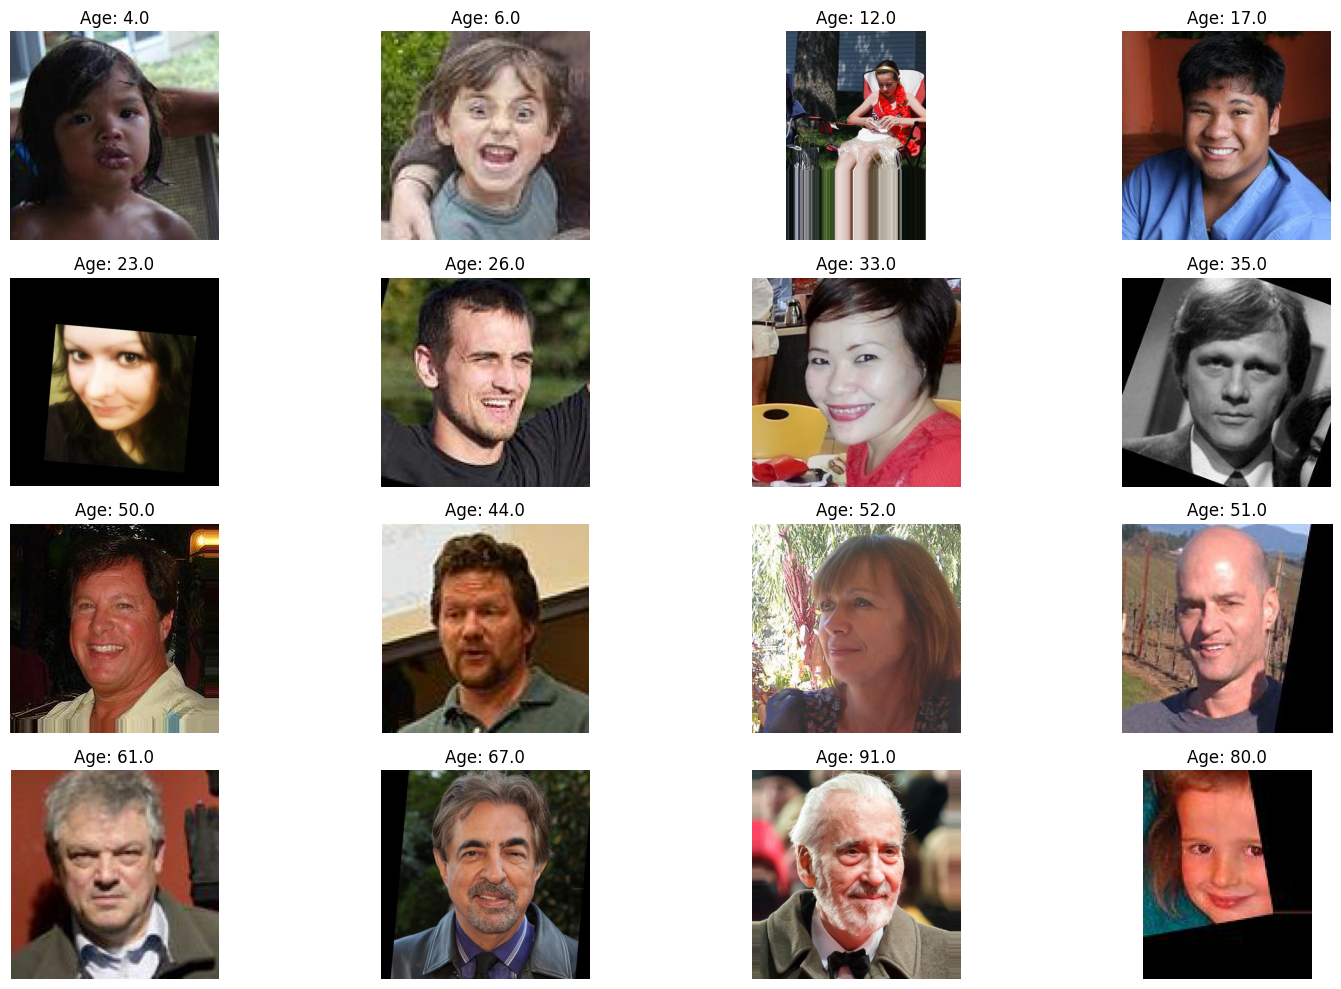

In [10]:
sample_df = (
    labels.groupby(pd.cut(labels['real_age'], bins=bins), observed=True)
          .sample(2, random_state=42)
          .reset_index(drop=True)
)

plt.figure(figsize=(16, 10))

for i, row in enumerate(sample_df.itertuples(index=False), start=1):
    img_path = os.path.join(labels_dir, row.file_name)
    img = Image.open(img_path)

    plt.subplot(4, 4, i)
    plt.imshow(img)
    plt.title(f"Age: {row.real_age:.1f}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Findings

- The dataset contains ~7.6k images listed in labels, with files stored in labels_dir.
- The target variable real_age is continuous, making this a regression problem.
- The age distribution is imbalanced, which may bias predictions toward common age ranges.
- Image variability suggests the need for augmentation and transfer learning.

## Modelling

Define the necessary functions to train your model on the GPU platform and build a single script containing all of them along with the initialization section.

To make this task easier, you can define them in this notebook and run a ready code in the next section to automatically compose the script.

The definitions below will be checked by project reviewers as well, so that they can understand how you built the model.

In [ ]:
import pandas as pd

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

In [11]:
def load_train(path):
    
    """
    It loads the train part of dataset from path
    """
    
    labels = pd.read_csv(os.path.join(path, 'labels.csv'))

    train_datagen = ImageDataGenerator(
        validation_split=0.25,
        rescale=1./255
    )

    train_gen_flow = train_datagen.flow_from_dataframe(
        dataframe=labels,
        directory=os.path.join(path, 'final_files'),
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        subset='training',
        seed=12345
    )
    return train_gen_flow

In [12]:
def load_test(path):
    
    """
    It loads the validation/test part of dataset from path
    """
    
    labels = pd.read_csv(os.path.join(path, 'labels.csv'))

    test_datagen = ImageDataGenerator(
        validation_split=0.25,
        rescale=1./255
    )

    test_gen_flow = test_datagen.flow_from_dataframe(
        dataframe=labels,
        directory=os.path.join(path, 'final_files'),
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        subset='validation',
        seed=12345
    )

    return test_gen_flow

In [16]:
def create_model(input_shape):
    
    """
    It defines model
    """
    
    backbone = ResNet50(weights='imagenet', 
                        input_shape=input_shape,
                        include_top=False)

    model = Sequential()
    model.add(backbone)
    model.add(GlobalAveragePooling2D())
    model.add(Dense(1, activation='relu'))

    optimizer = Adam(learning_rate=0.0005)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

    return model

In [17]:
def train_model(model, train_data, test_data, batch_size=None, epochs=20,
                steps_per_epoch=None, validation_steps=None):

    """
    Trains the model given the parameters
    """
    
    if steps_per_epoch is None:
        steps_per_epoch = len(train_data)
        
    if validation_steps is None:
        validation_steps = len(test_data)

    model.fit(train_data, 
              validation_data=test_data,
              batch_size=batch_size, epochs=epochs,
              steps_per_epoch=steps_per_epoch,
              validation_steps=validation_steps,
              verbose=2)

    return model

## Prepare the Script to Run on the GPU Platform

Given you've defined the necessary functions you can compose a script for the GPU platform, download it via the "File|Open..." menu, and to upload it later for running on the GPU platform.

N.B.: The script should include the initialization section as well. An example of this is shown below.

In [ ]:
# prepare a script to run on the GPU platform
init_str = """
import pandas as pd

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
"""

import inspect

with open('run_model_on_gpu.py', 'w') as f:
    
    f.write(init_str)
    f.write('\n\n')
        
    for fn_name in [load_train, load_test, create_model, train_model]:
        
        src = inspect.getsource(fn_name)
        f.write(src)
        f.write('\n\n')

### Output

Place the output from the GPU platform as an Markdown cell here.

Training Output (20 Epochs)

Epoch 1/20
356/356 - 35s - loss: 95.3532 - mae: 7.4339 - val_loss: 124.3362 - val_mae: 8.4921

Epoch 2/20
356/356 - 35s - loss: 76.8372 - mae: 6.6707 - val_loss: 127.6357 - val_mae: 8.6035

Epoch 3/20
356/356 - 35s - loss: 69.9428 - mae: 6.3992 - val_loss: 91.1531 - val_mae: 7.4454

Epoch 4/20
356/356 - 35s - loss: 64.4249 - mae: 6.1407 - val_loss: 124.0287 - val_mae: 8.3481

Epoch 5/20
356/356 - 35s - loss: 52.8486 - mae: 5.5913 - val_loss: 109.1004 - val_mae: 8.2192

Epoch 6/20
356/356 - 35s - loss: 46.3094 - mae: 5.2223 - val_loss: 85.1038 - val_mae: 7.0332

Epoch 7/20
356/356 - 35s - loss: 38.2617 - mae: 4.7951 - val_loss: 92.0900 - val_mae: 7.3359

Epoch 8/20
356/356 - 35s - loss: 37.4804 - mae: 4.7402 - val_loss: 80.0016 - val_mae: 6.7239

Epoch 9/20
356/356 - 35s - loss: 33.5237 - mae: 4.4271 - val_loss: 83.2579 - val_mae: 6.8529

Epoch 10/20
356/356 - 35s - loss: 28.5170 - mae: 4.1411 - val_loss: 83.5056 - val_mae: 6.9629

Epoch 11/20
356/356 - 35s - loss: 27.0142 - mae: 3.9700 - val_loss: 92.1290 - val_mae: 7.1866

Epoch 12/20
356/356 - 35s - loss: 27.4564 - mae: 4.0428 - val_loss: 185.6307 - val_mae: 11.4591

Epoch 13/20
356/356 - 35s - loss: 23.7961 - mae: 3.7407 - val_loss: 92.3429 - val_mae: 7.2467

Epoch 14/20
356/356 - 35s - loss: 24.6167 - mae: 3.8116 - val_loss: 92.4542 - val_mae: 7.1401

Epoch 15/20
356/356 - 35s - loss: 22.2604 - mae: 3.6746 - val_loss: 82.5822 - val_mae: 6.7841

Epoch 16/20
356/356 - 35s - loss: 20.1899 - mae: 3.4430 - val_loss: 86.3830 - val_mae: 6.8304

Epoch 17/20
356/356 - 35s - loss: 17.3425 - mae: 3.2205 - val_loss: 78.4369 - val_mae: 6.6419

Epoch 18/20
356/356 - 35s - loss: 16.5249 - mae: 3.1295 - val_loss: 81.7731 - val_mae: 6.7226

Epoch 19/20
356/356 - 35s - loss: 16.6140 - mae: 3.1421 - val_loss: 80.9727 - val_mae: 6.9908

Epoch 20/20
356/356 - 35s - loss: 17.0187 - mae: 3.1785 - val_loss: 93.4115 - val_mae: 7.6512


## Conclusions

### Model Training Results

I trained the model using a transfer learning approach with a frozen **ResNet50** backbone and a simple regression head on top. The training output from the GPU run was added to this notebook so that the full workflow (EDA → training → results) is documented in one place.

Across 20 epochs, the model showed steady improvement:

- Training MAE dropped from **7.43** in the first epoch to about **3.18** by the end.
- Validation MAE improved from **8.49** early on and stabilized around **6.6–7.6**.
- The best validation performance occurred around epochs **15–18**, with a minimum validation MAE of about **6.64**.

There was a noticeable spike in validation error around epoch 12, which likely reflects some overfitting or sensitivity to harder validation samples. This is expected given the imbalanced age distribution in the dataset. Overall, the results show that the model is learning useful age-related features and generalizes reasonably well to unseen data.

---

### Can Computer Vision Help the Customer?

Yes — computer vision can clearly help the customer in this case.

The model is able to estimate a person’s age from a facial image with an average error of roughly **6–7 years**. While this is not precise enough for tasks that require an exact age, it is more than sufficient for many practical use cases where approximate age information is enough. This allows the customer to automate processes that would otherwise require manual review, saving time and reducing human bias.

The results confirm that facial images contain enough visual information for age estimation and that a pretrained CNN can extract these patterns effectively, even with a moderately sized dataset.

---

### Other Practical Tasks the Customer Could Solve

Beyond predicting exact age, this model could be adapted or extended to solve other real-world problems:

- **Age group classification**  
  Grouping users into age ranges (for example, child, teenager, adult, senior), which is often more useful than predicting an exact number.

- **Content moderation and compliance**  
  Helping enforce age-restricted content rules by flagging users who are likely below a certain age threshold.

- **Personalization**  
  Using estimated age as an additional signal to personalize content, ads, or recommendations.

- **Demographic insights**  
  Aggregating predictions to understand the age distribution of users without requiring them to self-report demographic information.

- **Building larger vision pipelines**  
  Age estimation could be combined with other computer vision tasks like face detection or emotion recognition as part of a broader system.

---

### Final Takeaway

This project shows that computer vision is a practical and effective approach for automated age estimation. The current model provides a solid baseline, and its performance could be further improved by training longer, fine-tuning the upper layers of the pretrained network, applying stronger data augmentation, or addressing dataset imbalance.